In [1]:
# ── Celda 0 — Conexión y verificación de colecciones ──────────
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["upme_solar_db"]

colecciones = db.list_collection_names()
print("Conexión exitosa:", client.server_info()["version"])
print("Colecciones disponibles:", colecciones)

# Verificar que las tres colecciones requeridas existen
requeridas = ["municipios_pdet", "ms_buildings", "goo_buildings"]
for col in requeridas:
    n = db[col].count_documents({})
    print(f"  {col}: {n:,} documentos")

Conexión exitosa: 8.3.2
Colecciones disponibles: ['municipios_pdet', 'ms_buildings', 'goo_buildings']
  municipios_pdet: 170 documentos
  ms_buildings: 5,258 documentos
  goo_buildings: 2,263,446 documentos


In [2]:
# ── Celda 1 — Imports y referencias a colecciones ─────────────
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# Referencias a colecciones
col_mpio = db["municipios_pdet"]
col_ms   = db["ms_buildings"]
col_goo  = db["goo_buildings"]

# Carpeta de salida
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ Librerías cargadas")
print(f"📁 Outputs en: {OUTPUT_DIR.resolve()}")

✅ Librerías cargadas
📁 Outputs en: C:\Users\jtviv\outputs


In [3]:
# ── Celda 2 — Cargar municipios PDET desde GeoJSON ────────────
import geopandas as gpd

gdf_pdet = gpd.read_file(
    r"C:\Users\jtviv\OneDrive - Pontificia Universidad Javeriana\municipios_pdet.geojson"
)

print(f"✅ Municipios cargados: {len(gdf_pdet)}")
print(f"Columnas: {gdf_pdet.columns.tolist()}")
print(gdf_pdet[["cod_dane", "Municipio", "Departamento"]].head())

✅ Municipios cargados: 170
Columnas: ['dpto_ccdgo', 'mpio_ccdgo', 'mpio_cdpmp', 'dpto_cnmbr', 'mpio_cnmbr', 'mpio_crslc', 'mpio_tipo', 'mpio_narea', 'mpio_nano', 'shape_Leng', 'shape_Area', 'cod_dane', 'SubPDET', 'CodDept', 'Departamento', 'CodMuni', 'Municipio', 'area_km2', 'bbox', 'geometry']
  cod_dane Municipio Departamento
0    05031    AMALFI    ANTIOQUIA
1    05040     ANORÍ    ANTIOQUIA
2    05045  APARTADÓ    ANTIOQUIA
3    05107   BRICEÑO    ANTIOQUIA
4    05120   CÁCERES    ANTIOQUIA


In [4]:
# ── Celda 3 — Resultados por municipio: Google ────────────────
pipeline_goo = [
    {"$match": {"cod_dane_municipio": {"$ne": None}}},
    {"$group": {
        "_id":            "$cod_dane_municipio",
        "n_edificios":    {"$sum": 1},
        "area_total_m2":  {"$sum": "$area_m2"},
        "area_prom_m2":   {"$avg": "$area_m2"}
    }},
    {"$sort": {"area_total_m2": -1}}
]

rows_goo = []
for r in col_goo.aggregate(pipeline_goo):
    rows_goo.append({
        "cod_dane":      r["_id"],
        "n_edificios_goo":   r["n_edificios"],
        "area_total_goo":    round(r["area_total_m2"], 2),
        "area_prom_goo":     round(r["area_prom_m2"], 2)
    })

df_goo = pd.DataFrame(rows_goo)
print(f"✅ Municipios con datos Google: {len(df_goo)}")
print(df_goo.head(10).to_string(index=False))

✅ Municipios con datos Google: 164
cod_dane  n_edificios_goo  area_total_goo  area_prom_goo
   47001           154601     15042266.01          97.30
   20001           141586     14440557.18         101.99
   76109            88341      7104404.67          80.42
   18001            48674      6925916.84         142.29
   05837            66587      5607169.70          84.21
   47189            34439      3660305.00         106.28
   19698            30564      3588799.88         117.42
   52835            42556      3458019.47          81.26
   05045            30278      3343477.98         110.43
   81794            30013      3000073.12          99.96


In [5]:
# ── Celda 4 — Resultados por municipio: Microsoft ─────────────
pipeline_ms = [
    {"$match": {"cod_dane_municipio": {"$ne": None}}},
    {"$group": {
        "_id":           "$cod_dane_municipio",
        "n_edificios":   {"$sum": 1},
        "area_total_m2": {"$sum": "$area_m2"},
        "area_prom_m2":  {"$avg": "$area_m2"}
    }},
    {"$sort": {"area_total_m2": -1}}
]

rows_ms = []
for r in col_ms.aggregate(pipeline_ms):
    rows_ms.append({
        "cod_dane":        r["_id"],
        "n_edificios_ms":  r["n_edificios"],
        "area_total_ms":   round(r["area_total_m2"], 2),
        "area_prom_ms":    round(r["area_prom_m2"], 2)
    })

df_ms = pd.DataFrame(rows_ms)
print(f"✅ Municipios con datos Microsoft: {len(df_ms)}")
print(df_ms.to_string(index=False))

✅ Municipios con datos Microsoft: 2
cod_dane  n_edificios_ms  area_total_ms  area_prom_ms
   86573            4536       645665.1        142.34
   18756             722        56480.8         78.23


In [7]:
# ── Celda 5 — Tabla maestra: municipios + Google + Microsoft ──
df_resultado = gdf_pdet[["cod_dane", "Municipio", "Departamento", "SubPDET", "geometry"]].copy()

# Unir Google
df_resultado = df_resultado.merge(df_goo, on="cod_dane", how="left")

# Unir Microsoft
df_resultado = df_resultado.merge(df_ms, on="cod_dane", how="left")

# Rellenar NaN con 0 donde no hay datos
for col in ["n_edificios_goo", "area_total_goo", "area_prom_goo",
            "n_edificios_ms",  "area_total_ms",  "area_prom_ms"]:
    df_resultado[col] = df_resultado[col].fillna(0)

print(f"✅ Tabla maestra: {len(df_resultado)} municipios")
print(f"   Con datos Google:    {(df_resultado['n_edificios_goo'] > 0).sum()}")
print(f"   Con datos Microsoft: {(df_resultado['n_edificios_ms'] > 0).sum()}")
print(df_resultado[["cod_dane","Municipio","n_edificios_goo","area_total_goo","n_edificios_ms","area_total_ms"]].head())

✅ Tabla maestra: 170 municipios
   Con datos Google:    164
   Con datos Microsoft: 2
  cod_dane Municipio  n_edificios_goo  area_total_goo  n_edificios_ms  \
0    05031    AMALFI           2380.0       170505.65             0.0   
1    05040     ANORÍ           6272.0       454241.98             0.0   
2    05045  APARTADÓ          30278.0      3343477.98             0.0   
3    05107   BRICEÑO           2844.0       190009.90             0.0   
4    05120   CÁCERES          10325.0       897867.86             0.0   

   area_total_ms  
0            0.0  
1            0.0  
2            0.0  
3            0.0  
4            0.0  


In [9]:
# ── Celda 6 — Exportar tabla maestra a CSV ────────────────────
df_export = df_resultado.drop(columns=["geometry"])
df_export.to_csv(OUTPUT_DIR / "tabla_maestra_pdet.csv", index=False, encoding="utf-8")
print(f"✅ Exportada → outputs/tabla_maestra_pdet.csv")
print(f"   Filas: {len(df_export)}")

✅ Exportada → outputs/tabla_maestra_pdet.csv
   Filas: 170


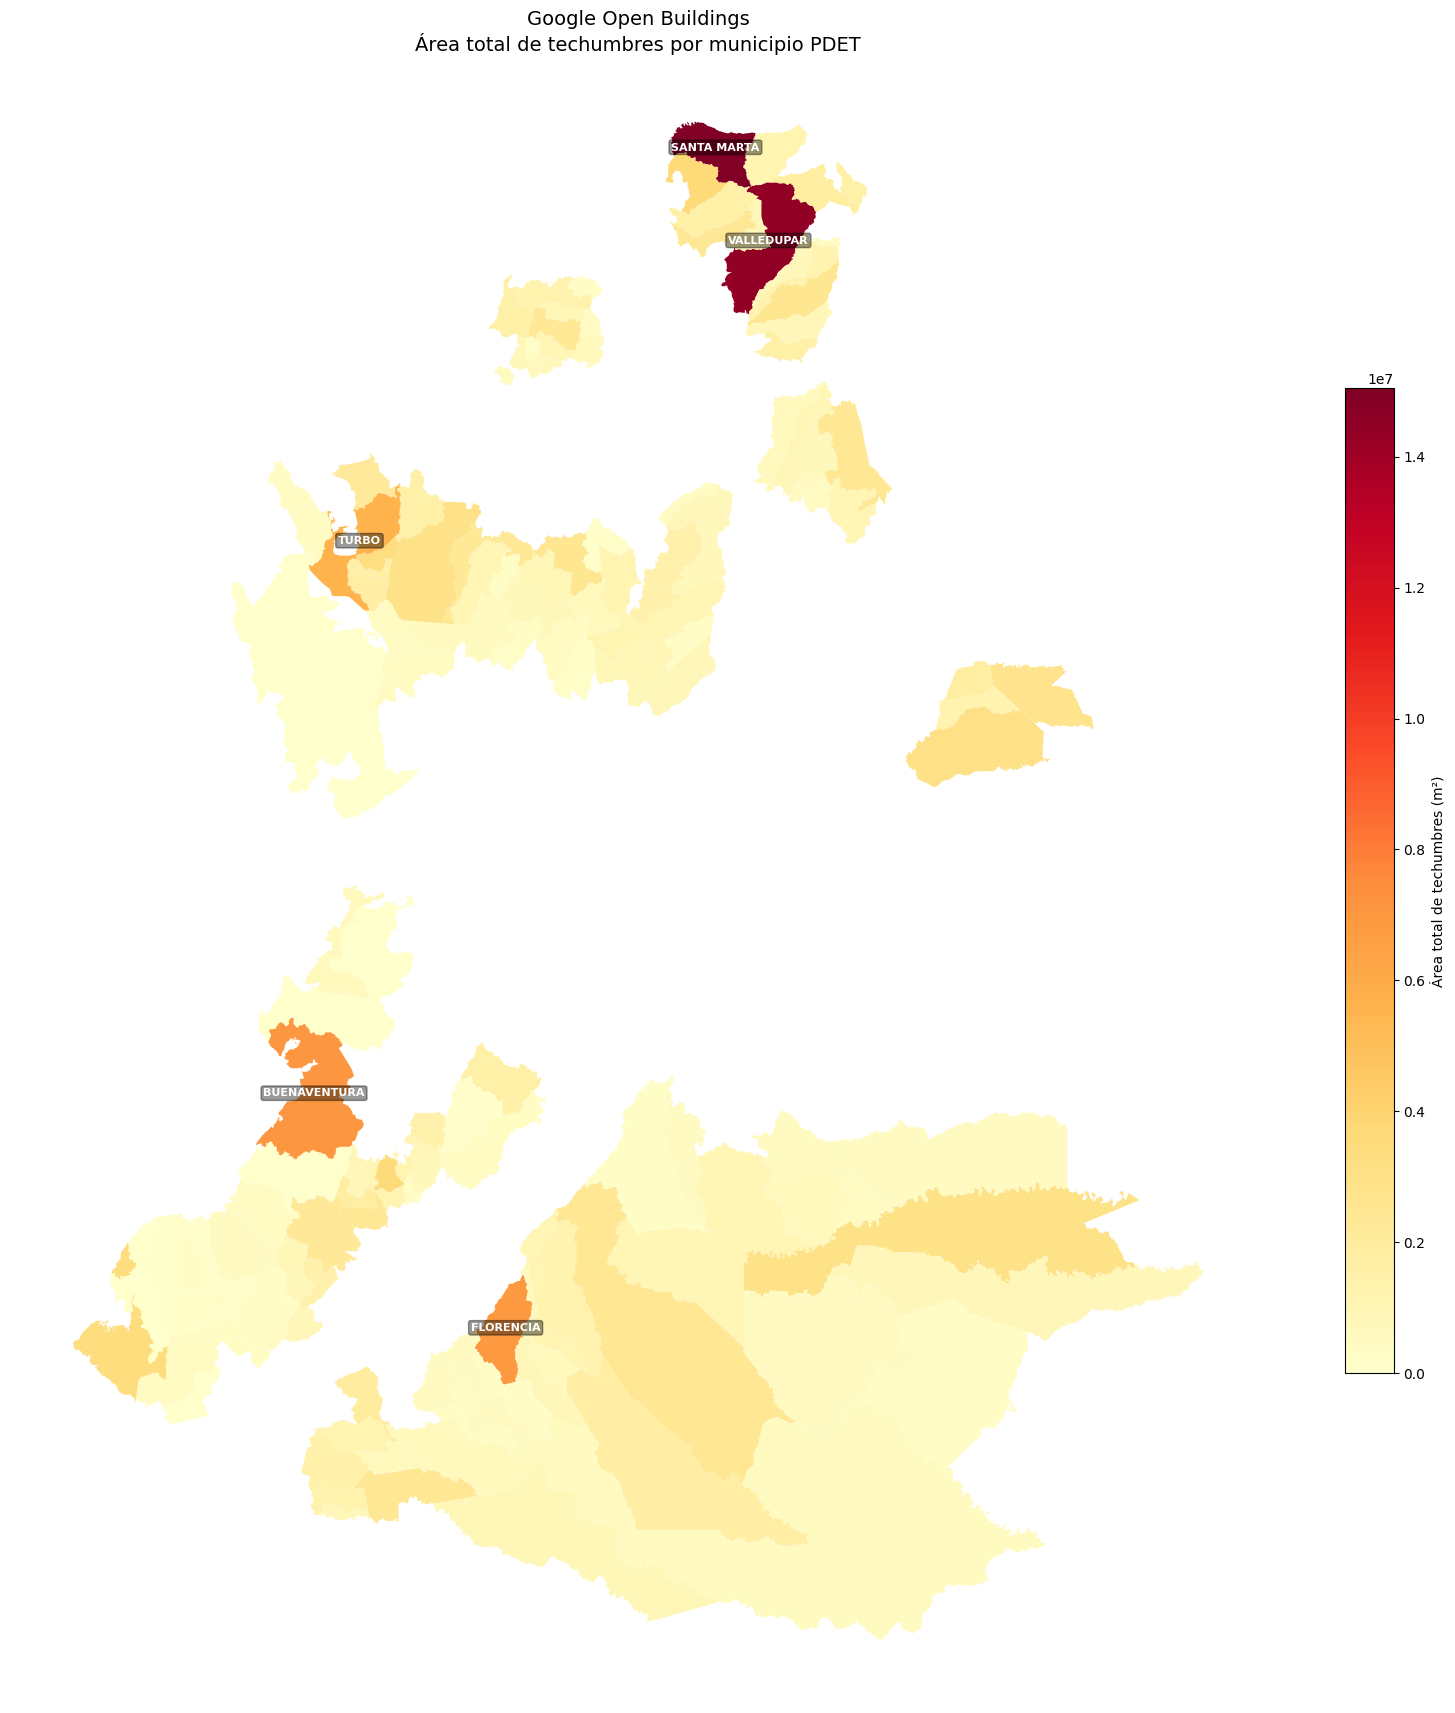

✅ Guardado → outputs/mapa_google.png


In [12]:
# ── Celda 7 — Mapa coroplético Google (corregido v2) ──────────
fig, ax = plt.subplots(1, 1, figsize=(16, 20))

df_resultado.plot(
    column="area_total_goo",
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
    legend_kwds={"label": "Área total de techumbres (m²)", "shrink": 0.5}
)

ax.set_title("Google Open Buildings\nÁrea total de techumbres por municipio PDET", fontsize=14)
ax.axis("off")

# Forzar límites para que quepan todos los municipios
bounds = df_resultado.total_bounds  # [minx, miny, maxx, maxy]
ax.set_xlim(bounds[0] - 0.5, bounds[2] + 0.5)
ax.set_ylim(bounds[1] - 0.5, bounds[3] + 0.5)

# Etiquetar Top 5
top5 = df_resultado.nlargest(5, "area_total_goo")
for _, row in top5.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["Municipio"],
        xy=(centroid.x, centroid.y),
        fontsize=8, ha="center", fontweight="bold", color="white",
        bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.4)
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mapa_google.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado → outputs/mapa_google.png")

In [13]:
# ── Celda 8 — Análisis de concordancia entre datasets ─────────

# Solo municipios con datos en AMBOS datasets
df_ambos = df_resultado[
    (df_resultado["n_edificios_goo"] > 0) &
    (df_resultado["n_edificios_ms"]  > 0)
].copy()

print(f"Municipios con datos en AMBOS datasets: {len(df_ambos)}")
print()

for _, row in df_ambos.iterrows():
    diff_edif = row["n_edificios_goo"] - row["n_edificios_ms"]
    diff_area = row["area_total_goo"]  - row["area_total_ms"]
    print(f"Municipio: {row['Municipio']} ({row['Departamento']})")
    print(f"  Edificios — Google: {row['n_edificios_goo']:,.0f} | Microsoft: {row['n_edificios_ms']:,.0f} | Diferencia: {diff_edif:+,.0f}")
    print(f"  Área (m²) — Google: {row['area_total_goo']:,.1f} | Microsoft: {row['area_total_ms']:,.1f} | Diferencia: {diff_area:+,.1f}")
    print()

# Nota sobre la limitación de Microsoft
print("=" * 60)
print("⚠️  LIMITACIÓN: Microsoft solo cubre 2 de 170 municipios PDET.")
print("    Esto se debe a que el tile descargado de Planetary Computer")
print("    no tiene cobertura completa para Colombia.")
print("    Google Open Buildings es el dataset principal del análisis.")

Municipios con datos en AMBOS datasets: 2

Municipio: SOLANO (CAQUETÁ)
  Edificios — Google: 5,121 | Microsoft: 722 | Diferencia: +4,399
  Área (m²) — Google: 567,560.3 | Microsoft: 56,480.8 | Diferencia: +511,079.5

Municipio: LEGUÍZAMO (PUTUMAYO)
  Edificios — Google: 8,772 | Microsoft: 4,536 | Diferencia: +4,236
  Área (m²) — Google: 899,945.0 | Microsoft: 645,665.1 | Diferencia: +254,279.9

⚠️  LIMITACIÓN: Microsoft solo cubre 2 de 170 municipios PDET.
    Esto se debe a que el tile descargado de Planetary Computer
    no tiene cobertura completa para Colombia.
    Google Open Buildings es el dataset principal del análisis.
